In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import cv2
from PIL import Image

from ultralytics import settings

# Update the default download directory
settings.update({"weights_dir": "/workspace/models"})

from ultralytics.nn.text_model import CLIP
from ultralytics import FastSAM

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fastsam_model = FastSAM(model="FastSAM-s.pt")

# Initialize Ultralytics CLIP wrapper
clip_model = CLIP(size="ViT-B/32", device=device)

In [5]:
local_image_path = '/workspace/projects/Grounded-Segment-Anything/assets/inpaint_demo.jpg'
image = Image.open(local_image_path)
image_np = np.array(image)

In [6]:
image_np.shape

(512, 512, 3)

In [7]:
IMG_W, IMG_H = image_np.shape[1], image_np.shape[0]

fastsam_results = fastsam_model(
    image_np,
    device=device,
    retina_masks=True,
    imgsz=image_np.shape[:2],
    conf=0.003,
    iou=0.25,
    max_det=100,
)
fastsam_masks = fastsam_results[0].masks.data.bool()

buffer = 10
kernel = np.ones((5, 5), np.uint8)
clip_input_list = []
for mask in fastsam_masks:
    mask_bool = (mask.cpu().numpy() > 0)
    if mask_bool.sum() == 0:
        continue

    # bounding box and dilation
    mask_u8 = (mask_bool.astype(np.uint8) * 255)
    x, y, w, h = cv2.boundingRect(mask_u8)
    x1, y1 = max(0, x - buffer), max(0, y - buffer)
    x2, y2 = min(IMG_W, x + w + buffer), min(IMG_H, y + h + buffer)


    dilated = cv2.dilate(mask_u8, kernel, iterations=3).astype(bool)
    if not dilated.any():
        continue

    # crop and zero-out background inside crop
    cropped_bb = image_np[y1:y2, x1:x2].copy()
    roi = dilated[y1:y2, x1:x2]
    cropped_bb[~roi] = 0
    try:
        pil_crop = Image.fromarray(cropped_bb)
    except Exception:
        pil_crop = Image.fromarray((np.clip(cropped_bb, 0, 255)).astype(np.uint8))

    clip_input_list.append(pil_crop)

# preprocess and batch for CLIP
preprocessed = [clip_model.image_preprocess(img).unsqueeze(0) for img in clip_input_list]
clip_input_batch = torch.cat(preprocessed, dim=0).to(device, non_blocking=True)

with torch.no_grad():
    fastsam_clip_embs_tensor = clip_model.encode_image(clip_input_batch)


0: 512x512 100 objects, 3.3ms
Speed: 6.8ms preprocess, 3.3ms inference, 263.1ms postprocess per image at shape (1, 3, 512, 512)


In [8]:
# 1. Encode text prompts
texts = ["a dog", "a bench"]
tokens = clip_model.tokenize(texts)
text_features = clip_model.encode_text(tokens)  # Output shape: [2, 512]

In [9]:
# Compute cosine similarity
# similarity = (fastsam_clip_embs_tensor @ text_features.T).softmax(dim=-1)
similarity = F.cosine_similarity(fastsam_clip_embs_tensor.unsqueeze(1), text_features.unsqueeze(0), dim=-1)
print(similarity.shape)

torch.Size([100, 2])


In [10]:
def plot_mask_overlay(image_np, mask_tensor, color=(255, 0, 0), alpha=0.5):
    """
    Overlays a boolean mask onto an RGB image.
    
    Parameters:
        image_np (np.ndarray): Original image as a NumPy array (H, W, 3).
        mask_tensor (torch.Tensor or np.ndarray): Boolean mask of shape (H, W).
        color (tuple): RGB color for the mask overlay (default: Red).
        alpha (float): Transparency factor for the mask (0.0 to 1.0).
    """
    # Convert PyTorch tensor to NumPy boolean array if needed
    if hasattr(mask_tensor, 'cpu'):
        mask = mask_tensor.cpu().numpy().astype(bool)
    else:
        mask = np.array(mask_tensor, dtype=bool)

    # Make a copy of the original image to avoid modifying in-place
    overlay = image_np.copy()

    # Apply color mask to designated pixels
    for c in range(3):
        overlay[:, :, c] = np.where(
            mask,
            (1 - alpha) * overlay[:, :, c] + alpha * color[c],
            overlay[:, :, c]
        )

    return overlay.astype(np.uint8)

Best mask for 'a dog': Mask Index=7, Score=0.2765


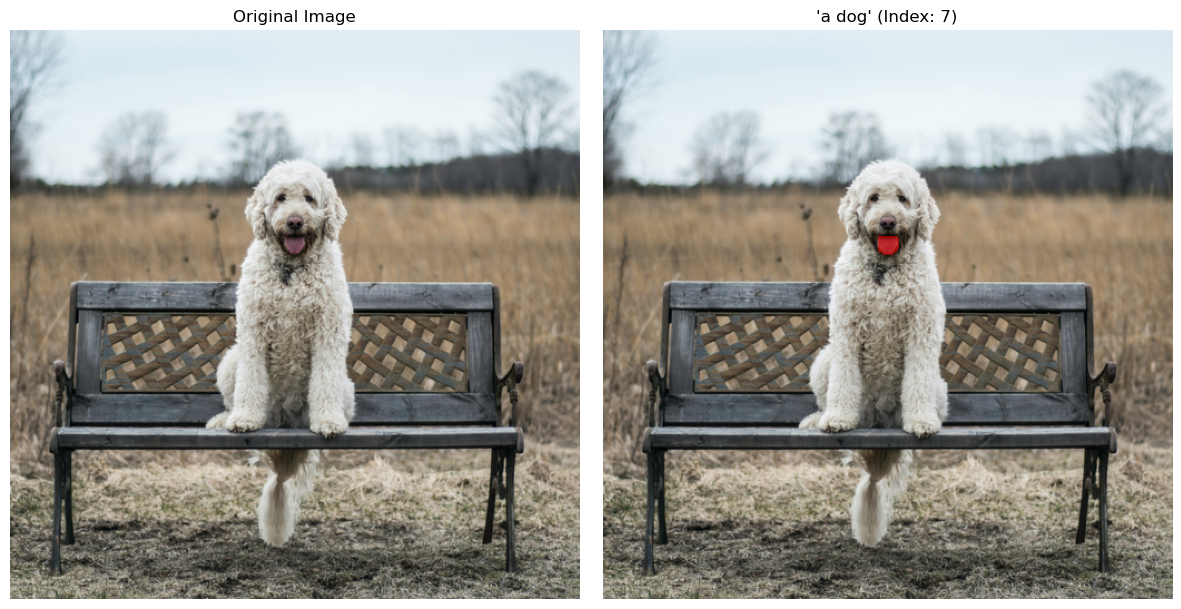

Best mask for 'a bench': Mask Index=21, Score=0.2694


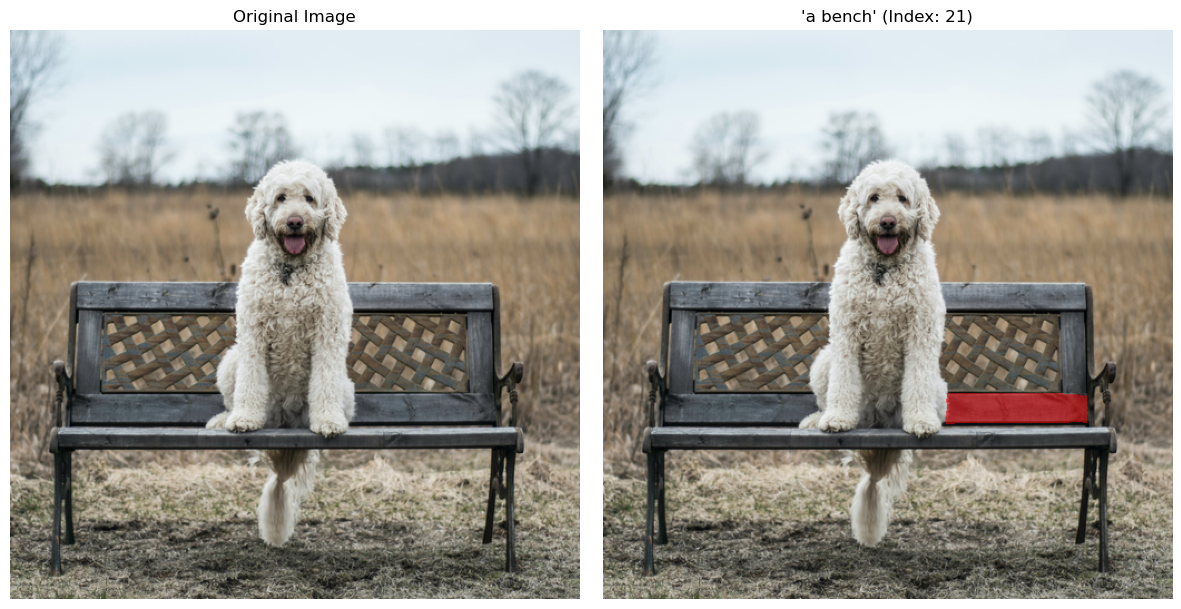

In [11]:
for t_idx in range(len(texts)):
    # print(f"Text prompt: {texts[t_idx]}")
    max_fsam_maskidx = similarity.argmax(dim=0)[t_idx]
    print(f"Best mask for '{texts[t_idx]}': Mask Index={max_fsam_maskidx}, Score={similarity[max_fsam_maskidx, t_idx].item():.4f}")

    # Generate the overlay image (Red overlay with 50% opacity)
    overlay_img = plot_mask_overlay(image_np, fastsam_masks[max_fsam_maskidx], color=(255, 0, 0), alpha=0.5)

    # Render side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(overlay_img)
    axes[1].set_title(f"'{texts[t_idx]}' (Index: {max_fsam_maskidx})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    

Text: 'a dog' | Merged 8 masks | Max Score: 0.2765


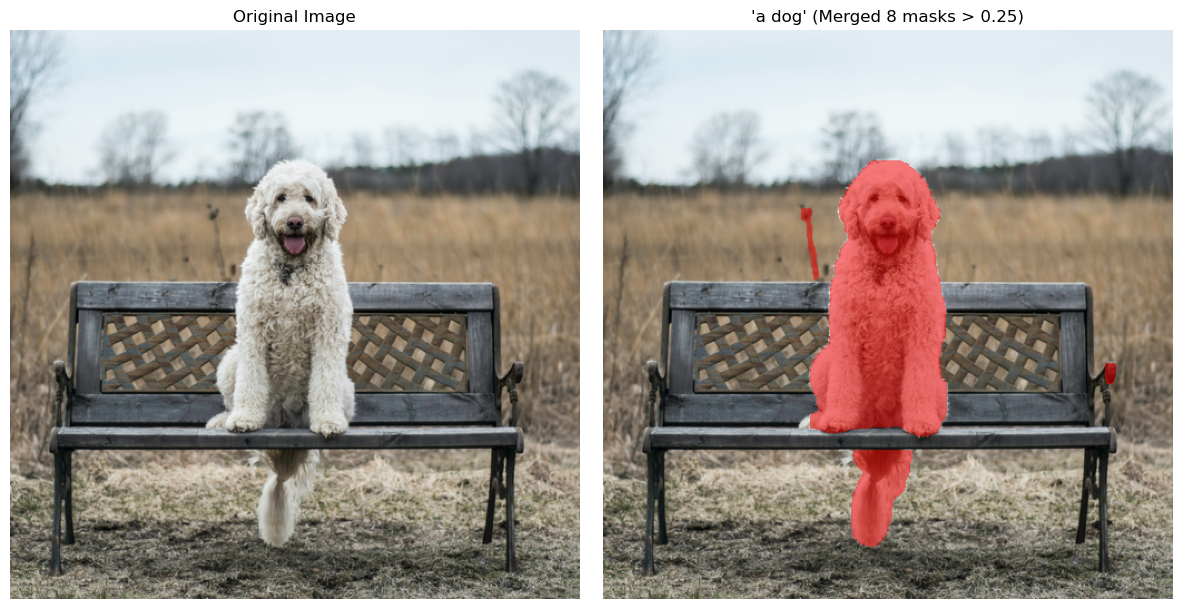

Text: 'a bench' | Merged 7 masks | Max Score: 0.2694


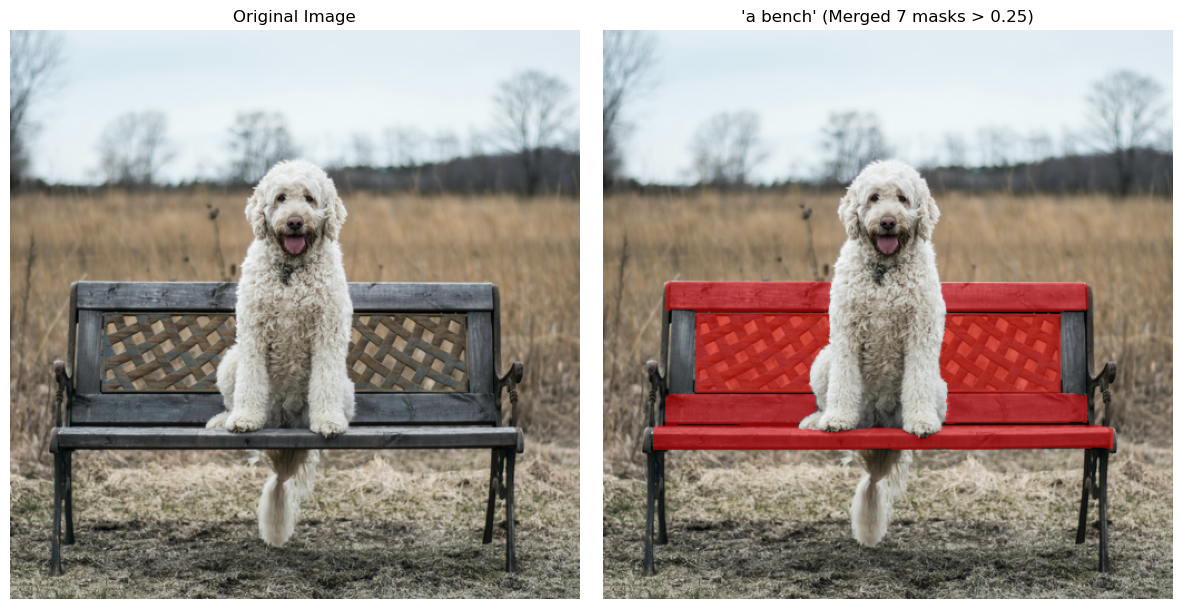

In [12]:
THRESHOLD = 0.25

for t_idx, text_prompt in enumerate(texts):
    # Get similarity scores for current text prompt across all masks: shape [N_masks]
    text_similarities = similarity[:, t_idx]
    
    # Identify indices of masks exceeding threshold
    passing_indices = (text_similarities > THRESHOLD).nonzero(as_tuple=True)[0]
    
    if len(passing_indices) == 0:
        print(f"No masks found for '{text_prompt}' above threshold {THRESHOLD}")
        continue

    # Extract masks above threshold: shape [K, H, W]
    selected_masks = fastsam_masks[passing_indices]
    
    # Merge selected masks along dimension 0 using bitwise OR
    merged_mask = selected_masks.any(dim=0)  # Equivalent to bitwise OR reduction across mask axis
    
    # Top score for display logging
    best_score = text_similarities[passing_indices].max().item()
    print(f"Text: '{text_prompt}' | Merged {len(passing_indices)} masks | Max Score: {best_score:.4f}")

    # Generate overlay image using merged boolean mask
    overlay_img = plot_mask_overlay(image_np, merged_mask, color=(255, 0, 0), alpha=0.5)

    # Render side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(overlay_img)
    axes[1].set_title(f"'{text_prompt}' (Merged {len(passing_indices)} masks > {THRESHOLD})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()